# Imports Explanation
Imports Ultralytics for YOLO model, OpenCV for image loading/processing, Matplotlib for visualization of detections and displaying results with bounding boxes.

In [1]:
from ultralytics import YOLO  # YOLO class from Ultralytics for loading and running the detection model.
import cv2  # OpenCV library for reading and manipulating images (e.g., drawing bounding boxes).
import matplotlib.pyplot as plt  # Matplotlib for plotting images with detections.

# Model Loading Explanation
Loads pre-trained YOLOv8 nano model (nano for speed) for object detection, using Ultralytics' from_pretrained-like method. Pre-trained on COCO for 80 classes.

In [2]:
model = YOLO('yolov8n.pt')  # Loads the pre-trained YOLOv8 nano model weights ('yolov8n.pt' downloads ~6MB if first time).

# Detection Explanation
Runs YOLO detection on an image, draws bounding boxes with labels/confidences, and displays the result.  This tests the model and visualizes the outputs.


image 1/1 c:\Users\rober\OneDrive\Desktop\Robert Damon AI Projects\Project 1\AI-Portfolio\object-detection\test_image.jpg: 448x640 5 persons, 19 cars, 1 traffic light, 1 umbrella, 233.7ms
Speed: 11.7ms preprocess, 233.7ms inference, 17.5ms postprocess per image at shape (1, 3, 448, 640)


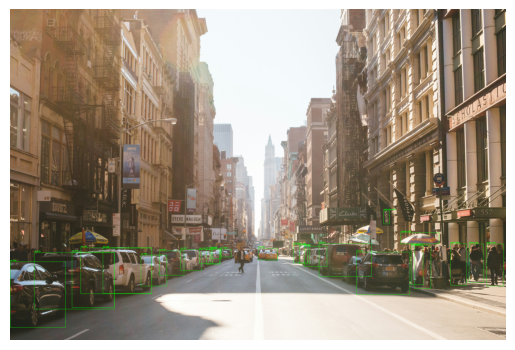

In [3]:
results = model('test_image.jpg')  # Runs detection on the image; returns results object with boxes, classes, confidences.
img = cv2.imread('test_image.jpg')  # Loads the image as a BGR array using OpenCV for drawing.
for r in results:  # Loops through detection results (one per image).
    for box in r.boxes:  # Loops through detected boxes.
        x1, y1, x2, y2 = map(int, box.xyxy[0])  # Extracts bounding box coordinates as integers.
        conf = box.conf.item()  # Gets confidence score as float.
        cls = int(box.cls.item())  # Gets class ID as int.
        label = f"{r.names[cls]} {conf:.2f}"  # Creates label with class name (from model's names dict) and confidence.
        cv2.rectangle(img, (x1, y1), (x2, y2), (0, 255, 0), 2)  # Draws green rectangle on image.
        cv2.putText(img, label, (x1, y1 - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 2)  # Adds label text above box.
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))  # Converts BGR to RGB for Matplotlib and displays image.
plt.axis('off')  # Hides axes for clean view.
plt.show()  # Shows the plotted image with detections.

# Testing with Your Own Photo Explanation
Runs detection on a custom photo, draws bounding boxes, and displays. Replace 'my_photo.jpg' with your file (e.g., transfer from phone).


image 1/1 c:\Users\rober\OneDrive\Desktop\Robert Damon AI Projects\Project 1\AI-Portfolio\object-detection\my_photo.jpg: 384x640 1 person, 3 cars, 1 dog, 190.4ms
Speed: 5.1ms preprocess, 190.4ms inference, 2.9ms postprocess per image at shape (1, 3, 384, 640)


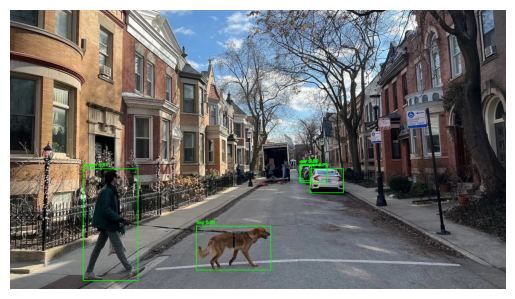

In [4]:
my_photo = 'my_photo.jpg'  # Path to your photo (save in folder, e.g., selfie.jpg).
results = model(my_photo)  # Runs detection on your photo.
img = cv2.imread(my_photo)  # Loads your photo.
for r in results:  # Loops results.
    for box in r.boxes:  # Loops boxes.
        x1, y1, x2, y2 = map(int, box.xyxy[0])  # Extracts coordinates.
        conf = box.conf.item()  # Gets confidence.
        cls = int(box.cls.item())  # Gets class ID.
        label = f"{r.names[cls]} {conf:.2f}"  # Creates label.
        cv2.rectangle(img, (x1, y1), (x2, y2), (0, 255, 0), 2)  # Draws box.
        cv2.putText(img, label, (x1, y1 - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 2)  # Adds label.
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))  # Converts to RGB.
plt.axis('off')  # Hides axes.
plt.show()  # Shows your photo with detections.

# Training Explanation
Fine-tunes YOLO on COCO128 subset; uses YAML for data config.

In [8]:
model.train(data='coco128.yaml', epochs=10, imgsz=320, batch=8, verbose=False)  # Trains on COCO128; imgsz=320 reduces image size for faster NMS/CPU; batch=8 lowers batch size to fit CPU memory and speed up.

New https://pypi.org/project/ultralytics/8.3.178 available  Update with 'pip install -U ultralytics'
Ultralytics 8.3.170  Python-3.12.3 torch-2.7.1+cpu CPU (Intel Core(TM) i7-1065G7 1.30GHz)
engine\trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=coco128.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=10, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=320, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=train3, nbs=64, nms=False, opset=None, optimize=False, optimize

train: Scanning C:\Users\rober\OneDrive\Desktop\Robert Damon AI Projects\Project 1\AI-Portfolio\object-detection\datasets\coco128\labels\train2017.cache... 126 images, 2 backgrounds, 0 corrupt: 100%|██████████| 128/128 [00:00<?, ?it/s]

val: Fast image access  (ping: 0.10.0 ms, read: 210.9118.8 MB/s, size: 52.5 KB)



c:\Users\rober\anaconda3\envs\ai_env\Lib\site-packages\torch\utils\data\dataloader.py:665: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
val: Scanning C:\Users\rober\OneDrive\Desktop\Robert Damon AI Projects\Project 1\AI-Portfolio\object-detection\datasets\coco128\labels\train2017.cache... 126 images, 2 backgrounds, 0 corrupt: 100%|██████████| 128/128 [00:00<?, ?it/s]

Plotting labels to runs\detect\train3\labels.jpg... 


...

                   all        128        929     0.0242     0.0251     0.0211      0.015



10 epochs completed in 0.142 hours.
Optimizer stripped from runs\detect\train3\weights\last.pt, 6.5MB
Optimizer stripped from runs\detect\train3\weights\best.pt, 6.5MB

Validating runs\detect\train3\weights\best.pt...
Ultralytics 8.3.170  Python-3.12.3 torch-2.7.1+cpu CPU (Intel Core(TM) i7-1065G7 1.30GHz)
Model summary (fused): 72 layers, 3,151,904 parameters, 0 gradients, 8.7 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:09<00:00,  1.20s/it]


                   all        128        929     0.0259     0.0246     0.0217      0.016
Speed: 1.0ms preprocess, 46.6ms inference, 0.0ms loss, 13.2ms postprocess per image
Results saved to runs\detect\train3


ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 11, 13, 14, 15, 16, 17, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 38, 39, 40, 41, 42, 43, 44, 45, 46, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 67, 68, 69, 71, 72, 73, 74, 75, 76, 77, 79])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x0000026EDE9DA3F0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027

# Debug Explanation
The below cell validates the model and prints mAP (Mean Average Precision); adjusts confidence for false positives.

In [9]:
metrics = model.val()  # Runs validation on val set from YAML; returns metrics like precision, recall, mAP.
print(metrics.box.map)  # Prints mAP at IoU 0.5 (higher = better, ~0.5 for short training).

Ultralytics 8.3.170  Python-3.12.3 torch-2.7.1+cpu CPU (Intel Core(TM) i7-1065G7 1.30GHz)
Model summary (fused): 72 layers, 3,151,904 parameters, 0 gradients, 8.7 GFLOPs
val: Fast image access  (ping: 0.30.2 ms, read: 53.736.3 MB/s, size: 36.5 KB)


val: Scanning C:\Users\rober\OneDrive\Desktop\Robert Damon AI Projects\Project 1\AI-Portfolio\object-detection\datasets\coco128\labels\train2017.cache... 126 images, 2 backgrounds, 0 corrupt: 100%|██████████| 128/128 [00:00<?, ?it/s]
c:\Users\rober\anaconda3\envs\ai_env\Lib\site-packages\torch\utils\data\dataloader.py:665: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 16/16 [00:05<00:00,  2.98it/s]


                   all        128        929     0.0283     0.0246     0.0235     0.0172
Speed: 0.7ms preprocess, 27.4ms inference, 0.0ms loss, 6.5ms postprocess per image
Results saved to runs\detect\train32
0.017183202013137895
